In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

In [2]:
np.random.seed(42)
n_students = 240
student_ids = [f"S{1000+i}" for i in range(n_students)]
students = pd.DataFrame({
"student_id": student_ids,
"gender": np.random.choice(["Female", "Male", "F", "M", "female", "male", None], n_students,
p=[0.28, 0.28, 0.10, 0.10, 0.10, 0.10, 0.04]),
"department": np.random.choice(["AI Engineering", "Computer Engineering", "Software Engineering",
"Industrial Engineering", "AI Eng.", "Comp Eng", None], n_students,
p=[0.30, 0.25, 0.18, 0.15, 0.06, 0.04, 0.02]),
"year": np.random.choice([1, 2, 3, 4], n_students, p=[0.45, 0.35, 0.12, 0.08]),
"scholarship_rate": np.random.choice([0, 25, 50, 75, 100, np.nan], n_students,
p=[0.30, 0.20, 0.20, 0.12, 0.15, 0.03])

})
weeks = pd.date_range("2025-02-03", periods=12, freq="W-MON")
activity_rows = []
for sid in student_ids:
    base_engagement = np.random.normal(6.5, 1.8)
    for week in weeks:
        study_hours = max(0, np.random.normal(base_engagement, 2.0))
        lms_logins = max(0, int(np.random.normal(base_engagement * 2.5, 5)))
        attendance_rate = np.clip(np.random.normal(0.78, 0.18), 0, 1)
        activity_rows.append([sid, week, study_hours, lms_logins, attendance_rate])
        activity = pd.DataFrame(activity_rows, columns=[
        "student_id", "week_start", "study_hours", "lms_logins", "attendance_rate"
])
# Intentional missing values
activity.loc[np.random.choice(activity.index, 50, replace=False), "study_hours"] = np.nan
activity.loc[np.random.choice(activity.index, 40, replace=False), "attendance_rate"] = np.nan
# Intentional impossible values and outliers
activity.loc[np.random.choice(activity.index, 8, replace=False), "study_hours"] = 80
activity.loc[np.random.choice(activity.index, 6, replace=False), "attendance_rate"] = 1.35
activity.loc[np.random.choice(activity.index, 6, replace=False), "lms_logins"] = -5
assessment = pd.DataFrame({
"student_id": student_ids,
"midterm_score": np.random.normal(68, 15, n_students),
"project_score": np.random.normal(72, 14, n_students),
"quiz_average": np.random.normal(70, 13, n_students)
})
# Intentional impossible assessment scores
assessment.loc[np.random.choice(assessment.index, 5, replace=False), "midterm_score"] = 130
assessment.loc[np.random.choice(assessment.index, 5, replace=False), "project_score"] = -10
assessment.loc[np.random.choice(assessment.index, 10, replace=False), "quiz_average"] = np.nan
campus = pd.DataFrame({
"student_id": student_ids,

"club_participation": np.random.choice(["Yes", "No", "yes", "no", "Y", "N", None], n_students,
p=[0.22, 0.38, 0.08, 0.12, 0.07, 0.10, 0.03]),
"library_visits": np.random.poisson(7, n_students),
"advisor_meetings": np.random.poisson(2, n_students)
})
# Generate final score with signal from engagement and assessments
activity_summary = activity.groupby("student_id").agg(
avg_study_hours=("study_hours", "mean"),
avg_lms_logins=("lms_logins", "mean"),
avg_attendance_rate=("attendance_rate", "mean")
).reset_index()
final = students.merge(activity_summary, on="student_id", how="left").merge(assessment, on="student_id",
how="left")
noise = np.random.normal(0, 7, n_students)
final_score = (
0.30 * final["midterm_score"].fillna(final["midterm_score"].median()) +
0.25 * final["project_score"].fillna(final["project_score"].median()) +
0.20 * final["quiz_average"].fillna(final["quiz_average"].median()) +
3.0 * final["avg_study_hours"].fillna(final["avg_study_hours"].median()) +
10.0 * final["avg_attendance_rate"].fillna(final["avg_attendance_rate"].median()) +
noise
)
grades = pd.DataFrame({
"student_id": student_ids,
"final_score": np.clip(final_score, 0, 100)
})
grades["risk_status"] = np.where(grades["final_score"] < 60, "At_Risk", "Not_At_Risk")
# Save raw files
students.to_csv("hw4_students_raw.csv", index=False)
activity.to_csv("hw4_weekly_activity_raw.csv", index=False)
assessment.to_csv("hw4_assessment_raw.csv", index=False)
campus.to_csv("hw4_campus_raw.csv", index=False)
grades.to_csv("hw4_grades_raw.csv", index=False)
print("Synthetic raw datasets created successfully.")

Synthetic raw datasets created successfully.


In [3]:
student_df = pd.read_csv("hw4_students_raw.csv")
w_activity_df = pd.read_csv("hw4_weekly_activity_raw.csv")
assessment_df = pd.read_csv("hw4_assessment_raw.csv")
campus_df = pd.read_csv("hw4_campus_raw.csv")
grades_df = pd.read_csv("hw4_grades_raw.csv")

# Assigning every csv documents to pandas DataFrame.

In [4]:
datas = [student_df, w_activity_df, assessment_df, campus_df, grades_df]
names = ["students", "w_activity", "assessment", "campus", "grades"]

for name, data in zip(names, datas):
    print(f" The shape of {name}: {data.shape}")
#Checking shapes of every datasets.

 The shape of students: (240, 5)
 The shape of w_activity: (2880, 5)
 The shape of assessment: (240, 4)
 The shape of campus: (240, 4)
 The shape of grades: (240, 3)


In [5]:
for name, data in zip(names, datas):
    print(name)
    print(data.head(5))
    print("-"*75)

students
  student_id  gender            department  year  scholarship_rate
0      S1000    Male              Comp Eng     2             100.0
1      S1001    male              Comp Eng     2               0.0
2      S1002       M               AI Eng.     2               0.0
3      S1003       F  Computer Engineering     2              75.0
4      S1004  Female        AI Engineering     2              50.0
---------------------------------------------------------------------------
w_activity
  student_id  week_start  study_hours  lms_logins  attendance_rate
0      S1000  2025-02-03     5.325414          14         0.526801
1      S1000  2025-02-10     4.989714          10         0.604343
2      S1000  2025-02-17     8.943464          12         1.000000
3      S1000  2025-02-24     7.822816          18         0.625496
4      S1000  2025-03-03     8.236800          14         0.801962
---------------------------------------------------------------------------
assessment
  student_id 

In [6]:
for name, data in zip(names, datas):
    print("|" + name + "| Columns |")
    print(data.columns)
    print("-"*90)

|students| Columns |
Index(['student_id', 'gender', 'department', 'year', 'scholarship_rate'], dtype='object')
------------------------------------------------------------------------------------------
|w_activity| Columns |
Index(['student_id', 'week_start', 'study_hours', 'lms_logins',
       'attendance_rate'],
      dtype='object')
------------------------------------------------------------------------------------------
|assessment| Columns |
Index(['student_id', 'midterm_score', 'project_score', 'quiz_average'], dtype='object')
------------------------------------------------------------------------------------------
|campus| Columns |
Index(['student_id', 'club_participation', 'library_visits',
       'advisor_meetings'],
      dtype='object')
------------------------------------------------------------------------------------------
|grades| Columns |
Index(['student_id', 'final_score', 'risk_status'], dtype='object')
-------------------------------------------------------------

In [7]:
for name, data in zip(names, datas):
    print("|" + name + "| Columns |")
    print(data.dtypes)
    print("-"*90)

|students| Columns |
student_id           object
gender               object
department           object
year                  int64
scholarship_rate    float64
dtype: object
------------------------------------------------------------------------------------------
|w_activity| Columns |
student_id          object
week_start          object
study_hours        float64
lms_logins           int64
attendance_rate    float64
dtype: object
------------------------------------------------------------------------------------------
|assessment| Columns |
student_id        object
midterm_score    float64
project_score    float64
quiz_average     float64
dtype: object
------------------------------------------------------------------------------------------
|campus| Columns |
student_id            object
club_participation    object
library_visits         int64
advisor_meetings       int64
dtype: object
------------------------------------------------------------------------------------------
|gr

#TASK1.2
(1)In the student.csv for each unique object represents students and there are 4 (gender,department,year,scholarship_rate) attiributes.

(2) In the w_activity.csv for each unique object(students) again there are 4 (week_start,study_hours,lms_logins,attendance_rate) attributes.

(3) In the assessment.csv for each unique object(students) there are 3
(midterm_score,project_score,quiz_average) attributes.

(4) In the campus.csv for each object(students) there are 3 (club_participation  library_visits,advisor_meetings) attributes.

(5) In the grades.csv for each object(students) there are 2(final_score,  risk_status) attributes.

-------------------------------------------------------------------------------------
1. student_id -> Nominal dtype -> discrete
2. risk_status -> Nominal dtype -> discrete
3. attendance_rate -> Ratio numberic -> continuous
4. week_start -> Date/Time -> discrete
5. lms_logins -> Ratio numeric count -> discrete
6. gender -> Nominal dtype -> discrete
7. library_visits -> Ratio numeric count -> discrete
8. study_hours -> Ratio numeric -> continuous
9. club_participation -> Nominal categorical -> discrete
10. quiz_average -> Ratio numeric -> continuous
-------------------------------------------------------------------------------------

In [8]:
for name, data in zip(names, datas):
    print("Column->" + name)
    print("-"*15)
    print(str(data.isnull().sum()))
    print("-"*25)

Column->students
---------------
student_id          0
gender              8
department          5
year                0
scholarship_rate    3
dtype: int64
-------------------------
Column->w_activity
---------------
student_id          0
week_start          0
study_hours        50
lms_logins          0
attendance_rate    40
dtype: int64
-------------------------
Column->assessment
---------------
student_id        0
midterm_score     0
project_score     0
quiz_average     10
dtype: int64
-------------------------
Column->campus
---------------
student_id            0
club_participation    6
library_visits        0
advisor_meetings      0
dtype: int64
-------------------------
Column->grades
---------------
student_id     0
final_score    0
risk_status    0
dtype: int64
-------------------------


#TASK 1.3

For student.csv there are totally 16 missing values. Most of them is in the gender, then department. For gender i will assing them to unknown. Additionally, for department i will the assign the mode because its not numeric.

For weekly activity there are totally 90 missing 50 hours, 40 attendance rate. For hours i will assign mean s_hours and for attendance rate again mean.

For assessment there are totally 10 missing values all of them in the quiz_avg. I am thinking for quiz_avg and i will assign mean value for missing values.

For Campus there are only 6 missing values and all of them comes from club_participation. Again i will assign the mode for missing values.

For grades thanks to data we dont have any missing values. No need to handle.

In [9]:
datas_modified = [student_df, assessment_df, campus_df, grades_df]
for name, data in zip(names, datas_modified):
    duplicated  = data[data["student_id"].duplicated()]
    print(F"Duplicated Rows length in {name}")
    print(len(duplicated))
    print("-"*70)
    
w_activity_dup = w_activity_df.duplicated(subset=["student_id", "week_start"])
print(F"Duplicated Rows length in w_activity")
print(w_activity_dup.sum())

Duplicated Rows length in students
0
----------------------------------------------------------------------
Duplicated Rows length in w_activity
0
----------------------------------------------------------------------
Duplicated Rows length in assessment
0
----------------------------------------------------------------------
Duplicated Rows length in campus
0
----------------------------------------------------------------------
Duplicated Rows length in w_activity
0


No duplicate student_id records were found in any dataset. Each student appears exactly once across students, assessment, campus, and grades tables. In the activity table, each student_id and week_start combination is unique, confirming 12 weekly records per student.

In [10]:
w_activity_df["attendance_rate"] = round(w_activity_df["attendance_rate"],2)
#There is no chance of students who attended half percent attendence record in history. so i rounded by 2.

assessment_df["midterm_score"] = round(assessment_df["midterm_score"],1)
assessment_df["project_score"] = round(assessment_df["project_score"],1)
assessment_df["quiz_average"] = round(assessment_df["quiz_average"],1)
#Its is more convenient when we use only 1 decimal points
grades_df["quiz_average"] = round(assessment_df["quiz_average"],1)

In [11]:
#Outlier detection and impossible values.
#For student_df
#student_impossible_year = student_df[(1 > student_df["year"]) | (student_df["year"] > 4)]
#print(f"Impossible rows in Student Years: {student_impossible_year}")

#student_impossible_scholarship_rate = student_df[(0.0 > student_df["scholarship_rate"]) | (student_df["scholarship_rate"] > 100.0)]
#print(f"Impossible rows in Student Scholarship_rate: {student_impossible_scholarship_rate

#For w_activity
#date = pd.to_datetime(w_activity_df["week_start"])
#years_impossible = date.dt.year[date.dt.year]
#years_impossible.value_counts()

#study hours
#Q1 = w_activity_df["study_hours"].quantile(0.25)
#Q3 = w_activity_df["study_hours"].quantile(0.75)

#IQR = round(Q3 - Q1, 2)
#Calculatin IQR to eliminate outliers

#Low_boundary = round(Q1 - (3*IQR)/2, 2) 
#Upper_boundary = round(Q3 + (3*IQR)/2, 2) 


#w_activity_Study_H_outliers = w_activity_df[(w_activity_df["study_hours"] < Low_boundary) | (w_activity_df["study_hours"] > Upper_boundary)]
#len(Study_H_outliers) # 23

#lms logins
#Q1 = w_activity_df["lms_logins"].quantile(0.25)
#Q3 = w_activity_df["lms_logins"].quantile(0.75)

#IQR = round(Q3 - Q1, 2)
#Calculatin IQR to eliminate outliers

#Low_boundary = round(Q1 - (3*IQR)/2, 2) 
#Upper_boundary = round(Q3 + (3*IQR)/2, 2) 

#w_activiyt_lms_outliers = w_activity_df[(w_activity_df["lms_logins"] < Low_boundary) | (w_activity_df["lms_logins"] > Upper_boundary)]
#len(w_activiyt_lms_outliers) # 16

#Impossible attendance rates.
#w_acticity_impossible_attendance = w_activity_df[(0.00 > w_activity_df["attendance_rate"]) | (w_activity_df["attendance_rate"] > 1.00)]
#len(w_acticity_impossible_attendance) #6

#Assesment_df
#assessment_impossible_midterm = assessment_df[(0.0 > assessment_df["midterm_score"]) | (assessment_df["midterm_score"] > 100.0)]
#assessment_impossible_project = assessment_df[(0.0 > assessment_df["project_score"]) | (assessment_df["project_score"] > 100.0)]
#assessment_impossible_quiz_avg = assessment_df[(0.0 > assessment_df["quiz_average"]) | (assessment_df["quiz_average"] > 100.0)]
#print(len(assessment_impossible_midterm)) #11
#print(len(assessment_impossible_project)) #9
#print(len(assessment_impossible_quiz_avg)) #

#Campus_df
#library visits
#Q1 = campus_df["library_visits"].quantile(0.25)
#Q3 = campus_df["library_visits"].quantile(0.75)

#IQR = round(Q3 - Q1, 2)
#Calculatin IQR to eliminate outliers

#Low_boundary = round(Q1 - (3*IQR)/2, 2) 
#Upper_boundary = round(Q3 + (3*IQR)/2, 2) 

#campus_library_visit_outliers = campus_df[(campus_df["library_visits"] < Low_boundary) | (campus_df["library_visits"] > Upper_boundary)]
#len(campus_library_visit_outliers) # 0

#Advisor meeting
#Q1 = campus_df["advisor_meetings"].quantile(0.25)
#Q3 = campus_df["advisor_meetings"].quantile(0.75)

#IQR = round(Q3 - Q1, 2)
#Calculatin IQR to eliminate outliers

#Low_boundary = round(Q1 - (3*IQR)/2, 2) 
#Upper_boundary = round(Q3 + (3*IQR)/2, 2) 

#campus_advisor_visit_outliers = campus_df[(campus_df["advisor_meetings"] < Low_boundary) | (campus_df["advisor_meetings"] > Upper_boundary)]
#len(campus_advisor_visit_outliers) #1

#Grades_df

#grades_impossible_fianl_s = grades_df[(0.0 > grades_df["final_score"]) | (grades_df["final_score"] > 100.0)]
#print(len(grades_impossible_fianl_s)) #0

In [12]:
# Invalid Year Analysis
student_impossible_year = student_df[(1 > student_df["year"]) | (student_df["year"] > 4)]
print(f"Impossible rows in Student Years: {len(student_impossible_year)}")
if not student_impossible_year.empty:
    print("Impossible Student Year Rows:")
    print(student_impossible_year)
print("-" * 40)

# Invalid Scholarship Rate Analysis
student_impossible_scholarship_rate = student_df[(0.0 > student_df["scholarship_rate"]) | (student_df["scholarship_rate"] > 100.0)]
print(f"Impossible rows in Student Scholarship Rate: {len(student_impossible_scholarship_rate)}")
if not student_impossible_scholarship_rate.empty:
    print("Impossible Student Scholarship Rate Rows:")
    print(student_impossible_scholarship_rate)
print("\n" + "="*50 + "\n")


# ==========================================
# 2. W_ACTIVITY_DF ANALYSIS
# ==========================================
print("--- W_ACTIVITY_DF ANALYSIS ---")

# Date Analysis (Year check)
date = pd.to_datetime(w_activity_df["week_start"])
print("Weekly Activity Year Distributions:")
print(date.dt.year.value_counts())
print("-" * 40)

# Study Hours Outliers (IQR)
Q1_sh = w_activity_df["study_hours"].quantile(0.25)
Q3_sh = w_activity_df["study_hours"].quantile(0.75)
IQR_sh = round(Q3_sh - Q1_sh, 2)
Low_boundary_sh = round(Q1_sh - (1.5 * IQR_sh), 2)
Upper_boundary_sh = round(Q3_sh + (1.5 * IQR_sh), 2)

w_activity_df["study_hours"] = round(w_activity_df["study_hours"],1)
w_activity_Study_H_outliers = w_activity_df[(w_activity_df["study_hours"] < Low_boundary_sh) | (w_activity_df["study_hours"] > Upper_boundary_sh)]
print(f"Study Hours Outlier Count: {len(w_activity_Study_H_outliers)}")
if not w_activity_Study_H_outliers.empty:
    print("Study Hours Outlier Rows:")
    print(w_activity_Study_H_outliers)
print("-" * 40)

# LMS Logins Outliers (IQR)
Q1_lms = w_activity_df["lms_logins"].quantile(0.25)
Q3_lms = w_activity_df["lms_logins"].quantile(0.75)
IQR_lms = round(Q3_lms - Q1_lms, 2)
Low_boundary_lms = round(Q1_lms - (1.5 * IQR_lms), 2)
Upper_boundary_lms = round(Q3_lms + (1.5 * IQR_lms), 2)

w_activity_lms_outliers = w_activity_df[(w_activity_df["lms_logins"] < Low_boundary_lms) | (w_activity_df["lms_logins"] > Upper_boundary_lms)]
print(f"LMS Logins Outlier Count: {len(w_activity_lms_outliers)}")
if not w_activity_lms_outliers.empty:
    print("LMS Logins Outlier Rows:")
    print(w_activity_lms_outliers)
print("-" * 40)

# Invalid Attendance Rates
w_activity_impossible_attendance = w_activity_df[(0.00 > w_activity_df["attendance_rate"]) | (w_activity_df["attendance_rate"] > 1.00)]
print(f"Impossible Attendance Rate Rows: {len(w_activity_impossible_attendance)}")
if not w_activity_impossible_attendance.empty:
    print("Impossible Attendance Rate Rows:")
    print(w_activity_impossible_attendance)
print("\n" + "="*50 + "\n")


# ==========================================
# 3. ASSESSMENT_DF ANALYSIS
# ==========================================
print("--- ASSESSMENT_DF ANALYSIS ---")

# Midterm Score
assessment_impossible_midterm = assessment_df[(0.0 > assessment_df["midterm_score"]) | (assessment_df["midterm_score"] > 100.0)]
print(f"Impossible Midterm Score Rows: {len(assessment_impossible_midterm)}")
if not assessment_impossible_midterm.empty:
    print("Impossible Midterm Score Rows:")
    print(assessment_impossible_midterm)
print("-" * 40)

# Project Score
assessment_impossible_project = assessment_df[(0.0 > assessment_df["project_score"]) | (assessment_df["project_score"] > 100.0)]
print(f"Impossible Project Score Rows: {len(assessment_impossible_project)}")
if not assessment_impossible_project.empty:
    print("Impossible Project Score Rows:")
    print(assessment_impossible_project)
print("-" * 40)

# Quiz Average
assessment_impossible_quiz_avg = assessment_df[(0.0 > assessment_df["quiz_average"]) | (assessment_df["quiz_average"] > 100.0)]
print(f"Impossible Quiz Average Rows: {len(assessment_impossible_quiz_avg)}")
if not assessment_impossible_quiz_avg.empty:
    print("Impossible Quiz Average Rows:")
    print(assessment_impossible_quiz_avg)
print("\n" + "="*50 + "\n")


# ==========================================
# 4. CAMPUS_DF ANALYSIS
# ==========================================
print("--- CAMPUS_DF ANALYSIS ---")

# Library Visits Outliers (IQR)
Q1_lib = campus_df["library_visits"].quantile(0.25)
Q3_lib = campus_df["library_visits"].quantile(0.75)
IQR_lib = round(Q3_lib - Q1_lib, 2)
Low_boundary_lib = round(Q1_lib - (1.5 * IQR_lib), 2)
Upper_boundary_lib = round(Q3_lib + (1.5 * IQR_lib), 2)

campus_library_visit_outliers = campus_df[(campus_df["library_visits"] < Low_boundary_lib) | (campus_df["library_visits"] > Upper_boundary_lib)]
print(f"Library Visits Outlier Count: {len(campus_library_visit_outliers)}")
if not campus_library_visit_outliers.empty:
    print("Library Visits Outlier Rows:")
    print(campus_library_visit_outliers)
print("-" * 40)

# Advisor Meetings Outliers (IQR)
Q1_adv = campus_df["advisor_meetings"].quantile(0.25)
Q3_adv = campus_df["advisor_meetings"].quantile(0.75)
IQR_adv = round(Q3_adv - Q1_adv, 2)
Low_boundary_adv = round(Q1_adv - (1.5 * IQR_adv), 2)
Upper_boundary_adv = round(Q3_adv + (1.5 * IQR_adv), 2)

campus_advisor_visit_outliers = campus_df[(campus_df["advisor_meetings"] < Low_boundary_adv) | (campus_df["advisor_meetings"] > Upper_boundary_adv)]
print(f"Advisor Meetings Outlier Count: {len(campus_advisor_visit_outliers)}")
if not campus_advisor_visit_outliers.empty:
    print("Advisor Meetings Outlier Rows:")
    print(campus_advisor_visit_outliers)
print("\n" + "="*50 + "\n")


# ==========================================
# 5. GRADES_DF ANALYSIS
# ==========================================
print("--- GRADES_DF ANALYSIS ---")

# Final Score
grades_impossible_final_s = grades_df[(0.0 > grades_df["final_score"]) | (grades_df["final_score"] > 100.0)]
print(f"Impossible Final Score Rows: {len(grades_impossible_final_s)}")
if not grades_impossible_final_s.empty:
    print("Impossible Final Score Rows:")
    print(grades_impossible_final_s)
print("\n" + "="*50)

Impossible rows in Student Years: 0
----------------------------------------
Impossible rows in Student Scholarship Rate: 0


--- W_ACTIVITY_DF ANALYSIS ---
Weekly Activity Year Distributions:
week_start
2025    2880
Name: count, dtype: int64
----------------------------------------
Study Hours Outlier Count: 23
Study Hours Outlier Rows:
     student_id  week_start  study_hours  lms_logins  attendance_rate
64        S1005  2025-03-03         13.6          19             0.51
125       S1010  2025-03-10         14.1          29             0.74
128       S1010  2025-03-31         13.6          26             0.80
539       S1044  2025-04-21         80.0          15             0.93
704       S1058  2025-03-31         80.0          20             1.00
854       S1071  2025-02-17         14.1          30             0.82
860       S1071  2025-03-31         14.3          22             0.87
924       S1077  2025-02-03         80.0          26             0.84
977       S1081  2025-03-10   

In [13]:
#Inconsistent categorial labels.

print(student_df["gender"].value_counts())
print("-" * 40)
print(campus_df["club_participation"].value_counts())
print("-" * 40)
print(student_df["department"].value_counts())

gender
Female    75
Male      63
F         27
male      26
female    21
M         20
Name: count, dtype: int64
----------------------------------------
club_participation
No     87
Yes    52
no     31
yes    27
Y      20
N      17
Name: count, dtype: int64
----------------------------------------
department
AI Engineering            68
Computer Engineering      58
Software Engineering      40
Industrial Engineering    39
Comp Eng                  17
AI Eng.                   13
Name: count, dtype: int64


#Task 1.3 Insights

This data quality analysis checks five interconnected datasets (student_df, w_activity_df, assessment_df, campus_df, and grades_df) to identify and isolate logical anomalies, statistical outliers, and categorical inconsistencies. It parses the week_start column into datetime format to verify timeline consistency and flag any unexpected years, while scanning for impossible values that defy real-world boundaries—such as academic years outside the 1–4 range, scholarship or grade rates escaping the 0–100 scale, and attendance percentages dropping below 0.0 or exceeding 1.0. For behavioral metrics like study hours, LMS logins, library visits, and advisor meetings, the script calculates the Interquartile Range (IQR) with standard whiskers (1.5×IQR) to flag extreme statistical outliers. Finally, it uses frequency distributions to check categorical columns (gender, club_participation, and department) for structural text issues like typos, mixed casing, or inconsistent naming conventions that could corrupt future analytical models.

In [14]:
#Task 2

In [15]:
student_df["gender"].value_counts()
#Checking beforehand to know unique values.

gender
Female    75
Male      63
F         27
male      26
female    21
M         20
Name: count, dtype: int64

In [16]:
student_df["department"].value_counts()
#Checking beforehand to know unique values.

department
AI Engineering            68
Computer Engineering      58
Software Engineering      40
Industrial Engineering    39
Comp Eng                  17
AI Eng.                   13
Name: count, dtype: int64

In [17]:
campus_df["club_participation"].value_counts()
#Checking beforehand to know unique values.

club_participation
No     87
Yes    52
no     31
yes    27
Y      20
N      17
Name: count, dtype: int64

In [18]:
Standardize_map_gender = {
    "Male" : "M",
    "male" : "M",
    "M" : "M",
    "F" : "F",
    "Female" : "F",
    "female" : "F"
}
student_df["gender"] = student_df["gender"].map(Standardize_map_gender)
print(f"Unique genders:   {student_df["gender"].unique()}")

Standardize_map_department = {
    "Comp Eng" : "Computer Engineering",
    "AI Eng" : "AI Engineering",
    "Computer Engineering" : "Computer Engineering",
    "AI Engineering" : "AI Engineering",
    "Industrial Engineering" : "Industrial Engineering",
    "Software Engineering" : "Software Engineering"
}
student_df["department"] = student_df["department"].map(Standardize_map_department)
print(f"Unique departments:   {student_df["department"].unique()}")

Standardize_map_club_participation =  {
    "Yes" : "Y",
    "yes" : "Y",
    "Y" : "Y",
    "No" : "N",
    "no" : "N",
    "N" : "N"
}
campus_df["club_participation"] = campus_df["club_participation"].map(Standardize_map_club_participation)
print(f"Unique club_participation:   {campus_df["club_participation"].unique()}")

Unique genders:   ['M' 'F' nan]
Unique departments:   ['Computer Engineering' nan 'AI Engineering' 'Industrial Engineering'
 'Software Engineering']
Unique club_participation:   ['Y' 'N' nan]


In [19]:
print(student_df["gender"].value_counts())
print(student_df["department"].value_counts())
print(campus_df["club_participation"].value_counts())

gender
F    123
M    109
Name: count, dtype: int64
department
Computer Engineering      75
AI Engineering            68
Software Engineering      40
Industrial Engineering    39
Name: count, dtype: int64
club_participation
N    135
Y     99
Name: count, dtype: int64


In [20]:
#Task 2.2

In [21]:
student_df["gender"] = student_df["gender"].fillna("Unknown")
print(student_df["gender"].value_counts())
# Because of we dont know gender the best approach should be assigning to unknown. For all 3 cases.
print("-" * 40)
student_df["department"] = student_df["department"].fillna("Unknown")
print(student_df["department"].value_counts())
print("-" * 40)
campus_df["club_participation"] = campus_df["club_participation"].fillna("Unknown")
print(campus_df["club_participation"].value_counts())

#In here i assigned as Unknown because deleting rows for only 1 missing/malformed/outlier shouldn't affect entire row then i changed as unknown.


gender
F          123
M          109
Unknown      8
Name: count, dtype: int64
----------------------------------------
department
Computer Engineering      75
AI Engineering            68
Software Engineering      40
Industrial Engineering    39
Unknown                   18
Name: count, dtype: int64
----------------------------------------
club_participation
N          135
Y           99
Unknown      6
Name: count, dtype: int64


In [22]:
#Task 2.3 has to executed first before 2.2 because i dont want median affected by outliers.


In [23]:
w_activity_df["study_hours"] = w_activity_df["study_hours"].replace(80, np.nan)
w_activity_df["study_hours"] = round(w_activity_df["study_hours"], 1)
w_activity_df
#Values above the IQR upper boundary were reviewed manually. Only the value of 80 was treated as impossible
#and replaced with NaN as weekly study hours of 13-16 are realistic for university students.

,student_id,week_start,study_hours,lms_logins,attendance_rate
0,S1000,2025-02-03,5.3,14,0.53
1,S1000,2025-02-10,5.0,10,0.60
2,S1000,2025-02-17,8.9,12,1.00
3,S1000,2025-02-24,7.8,18,0.63
4,S1000,2025-03-03,8.2,14,0.80
...,...,...,...,...,...
2875,S1239,2025-03-24,NaN,17,0.44
2876,S1239,2025-03-31,7.0,21,0.96
2877,S1239,2025-04-07,5.6,24,0.66
2878,S1239,2025-04-14,8.7,17,0.81


In [24]:
w_activity_df.loc[w_activity_lms_outliers.index, "lms_logins"] = np.nan
#After i found outliers i used .loc[index_version_outlier, column] = np.nan
w_activity_df.loc[w_activity_impossible_attendance.index, "attendance_rate"] = np.nan
assessment_df.loc[assessment_impossible_midterm.index, "midterm_score"] = np.nan
assessment_df.loc[assessment_impossible_project.index, "project_score"] = np.nan
assessment_df.loc[assessment_impossible_quiz_avg.index, "quiz_average"] = np.nan

final_score_immposible = grades_df[(0.0 > grades_df["final_score"]) | (grades_df["final_score"] > 100.0)]
#print(final_score_immposible) # No single row in here so no need to fix anything
#In here i detect all impossible scenarios including outliers, missing data, malformed data. this detection done in earlier cells where everything handeled.
#After careful examination i came across some negative values, extreme values... in here i turn all of them into nan. Also some of the addendance rates was outside of the 
#normal fixed interval. Additionally, exam scores, project score all of them handeled and tured into unknown category. Lastly, i checked dates to make it more reliable
assessment_df.isnull().sum()

student_id        0
midterm_score    11
project_score     9
quiz_average     15
dtype: int64

In [25]:
student_df["scholarship_rate"] = student_df["scholarship_rate"].fillna(np.nanmedian(student_df["scholarship_rate"]))
print(student_df["scholarship_rate"].value_counts())
print("-" * 40)
w_activity_df["study_hours"] = w_activity_df["study_hours"].fillna(np.nanmedian(w_activity_df["study_hours"]))
print(w_activity_df["study_hours"].value_counts())
print("-" * 40)
w_activity_df["attendance_rate"] = w_activity_df["attendance_rate"].fillna(np.nanmedian(w_activity_df["attendance_rate"]))
print(w_activity_df["attendance_rate"].value_counts())
print("-" * 40)
assessment_df["quiz_average"] = assessment_df["quiz_average"].fillna(np.nanmedian(assessment_df["quiz_average"]))
print(assessment_df["quiz_average"].value_counts())
print("-" * 40)
assessment_df["midterm_score"] = assessment_df["midterm_score"].fillna(np.nanmedian(assessment_df["midterm_score"]))
print("-" * 40)
assessment_df["project_score"] = assessment_df["project_score"].fillna(np.nanmedian(assessment_df["project_score"]))

#Task 2.2 is after 2.3, i stated why after in earlier cells.
#In here i selected all NaN values across all related columns then used fillna to assing values i used median is the convinient way.

scholarship_rate
0.0      78
50.0     51
25.0     47
100.0    39
75.0     25
Name: count, dtype: int64
----------------------------------------
study_hours
6.2     107
6.0      53
5.2      52
5.9      51
6.1      51
       ... 
13.4      1
14.2      1
15.8      1
12.3      1
14.6      1
Name: count, Length: 140, dtype: int64
----------------------------------------
attendance_rate
1.00    354
0.78    116
0.73     77
0.82     68
0.74     68
       ... 
0.24      1
0.26      1
0.37      1
0.27      1
0.13      1
Name: count, Length: 76, dtype: int64
----------------------------------------
quiz_average
71.3    17
68.2     3
77.2     3
64.6     3
71.2     3
        ..
96.8     1
73.6     1
47.3     1
80.2     1
66.4     1
Name: count, Length: 174, dtype: int64
----------------------------------------
----------------------------------------


In [26]:
#Task 2.4

In [27]:
student_df.to_csv("hw4_cleaned_student_df.csv", index=False)
w_activity_df.to_csv("hw4_cleaned_w_activitiy_df.csv", index=False)
assessment_df.to_csv("hw4_cleaned_assessment_df.csv", index=False)
campus_df.to_csv("hw4_cleaned_campus_df.csv", index=False)
grades_df.to_csv("hw4_cleaned_grades_df.csv", index=False)
#Saving all df as csv file.

In [28]:
map_ = {
  "study_hours": ["mean", "sum"],
  "lms_logins": ["mean", "sum"],
  "attendance_rate": ["mean"],
  "week_start": ["count"]
}
new_w_activity_df = w_activity_df.groupby("student_id").agg(map_)
#Whit this we reduced row count by 12 there were 12 records for each student. 
#After performing these code there will be only one line for each student.
new_w_activity_df.columns = ["_".join(col) for col in new_w_activity_df.columns]
new_w_activity_df

,study_hours_mean,study_hours_sum,lms_logins_mean,lms_logins_sum,attendance_rate_mean,week_start_count
student_id,,,,,,
S1000,7.125000,85.5,15.083333,181.0,0.817500,12
S1001,8.050000,96.6,18.833333,226.0,0.787500,12
S1002,5.450000,65.4,13.500000,162.0,0.818333,12
S1003,7.316667,87.8,21.333333,256.0,0.844167,12
S1004,9.766667,117.2,21.750000,261.0,0.806667,12
...,...,...,...,...,...,...
S1235,5.775000,69.3,13.916667,167.0,0.774167,12
S1236,6.766667,81.2,16.583333,199.0,0.811667,12
S1237,4.600000,55.2,10.416667,125.0,0.776667,12


In [29]:
#Task3.2

In [30]:
merged_df = pd.merge(student_df,assessment_df, on = "student_id", how = "left")
merged_df = pd.merge(merged_df,campus_df, on = "student_id", how = "left")
merged_df = pd.merge(merged_df,new_w_activity_df, on = "student_id", how = "left")
merged_df = pd.merge(merged_df,grades_df, on = "student_id", how = "left")
merged_df.shape
#merging files into a one file.

(240, 20)

In [31]:
merged_df

,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average_x,club_participation,library_visits,advisor_meetings,study_hours_mean,study_hours_sum,lms_logins_mean,lms_logins_sum,attendance_rate_mean,week_start_count,final_score,risk_status,quiz_average_y
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,1,7.125000,85.5,15.083333,181.0,0.817500,12,86.443755,Not_At_Risk,73.4
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,2,8.050000,96.6,18.833333,226.0,0.787500,12,78.634579,Not_At_Risk,76.8
2,S1002,M,Unknown,2,0.0,49.9,76.6,83.1,N,4,1,5.450000,65.4,13.500000,162.0,0.818333,12,56.559696,At_Risk,83.1
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,5,7.316667,87.8,21.333333,256.0,0.844167,12,86.158871,Not_At_Risk,82.0
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,1,9.766667,117.2,21.750000,261.0,0.806667,12,68.606180,Not_At_Risk,59.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Unknown,4,25.0,85.8,49.3,66.5,Y,5,0,5.775000,69.3,13.916667,167.0,0.774167,12,71.222566,Not_At_Risk,66.5
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,0,6.766667,81.2,16.583333,199.0,0.811667,12,84.638368,Not_At_Risk,60.5
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,3,4.600000,55.2,10.416667,125.0,0.776667,12,72.375301,Not_At_Risk,60.8
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,2,8.075000,96.9,17.333333,208.0,0.639167,12,89.100227,Not_At_Risk,71.5


In [32]:
merged_df = merged_df.drop(columns=['quiz_average_y'])
merged_df
#there were 2 identical columns so i droped oen of them.

,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average_x,club_participation,library_visits,advisor_meetings,study_hours_mean,study_hours_sum,lms_logins_mean,lms_logins_sum,attendance_rate_mean,week_start_count,final_score,risk_status
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,1,7.125000,85.5,15.083333,181.0,0.817500,12,86.443755,Not_At_Risk
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,2,8.050000,96.6,18.833333,226.0,0.787500,12,78.634579,Not_At_Risk
2,S1002,M,Unknown,2,0.0,49.9,76.6,83.1,N,4,1,5.450000,65.4,13.500000,162.0,0.818333,12,56.559696,At_Risk
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,5,7.316667,87.8,21.333333,256.0,0.844167,12,86.158871,Not_At_Risk
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,1,9.766667,117.2,21.750000,261.0,0.806667,12,68.606180,Not_At_Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Unknown,4,25.0,85.8,49.3,66.5,Y,5,0,5.775000,69.3,13.916667,167.0,0.774167,12,71.222566,Not_At_Risk
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,0,6.766667,81.2,16.583333,199.0,0.811667,12,84.638368,Not_At_Risk
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,3,4.600000,55.2,10.416667,125.0,0.776667,12,72.375301,Not_At_Risk
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,2,8.075000,96.9,17.333333,208.0,0.639167,12,89.100227,Not_At_Risk


In [33]:
merged_df = merged_df.rename(columns={'quiz_average_x': 'quiz_average'})
#i changed the name of the quiz_average_x because there only 1 column

In [34]:
merged_df

,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average,club_participation,library_visits,advisor_meetings,study_hours_mean,study_hours_sum,lms_logins_mean,lms_logins_sum,attendance_rate_mean,week_start_count,final_score,risk_status
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,1,7.125000,85.5,15.083333,181.0,0.817500,12,86.443755,Not_At_Risk
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,2,8.050000,96.6,18.833333,226.0,0.787500,12,78.634579,Not_At_Risk
2,S1002,M,Unknown,2,0.0,49.9,76.6,83.1,N,4,1,5.450000,65.4,13.500000,162.0,0.818333,12,56.559696,At_Risk
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,5,7.316667,87.8,21.333333,256.0,0.844167,12,86.158871,Not_At_Risk
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,1,9.766667,117.2,21.750000,261.0,0.806667,12,68.606180,Not_At_Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Unknown,4,25.0,85.8,49.3,66.5,Y,5,0,5.775000,69.3,13.916667,167.0,0.774167,12,71.222566,Not_At_Risk
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,0,6.766667,81.2,16.583333,199.0,0.811667,12,84.638368,Not_At_Risk
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,3,4.600000,55.2,10.416667,125.0,0.776667,12,72.375301,Not_At_Risk
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,2,8.075000,96.9,17.333333,208.0,0.639167,12,89.100227,Not_At_Risk


In [35]:
merged_df["high_attendance"] = np.where(merged_df["attendance_rate_mean"] >= 0.80, 1, 0)

In [36]:
from sklearn.preprocessing import LabelEncoder

merged_df["high_study_hours"] = np.where(merged_df["study_hours_sum"] >= 95.0, 1, 0)
#if the student has more study hours than 95 hours S/he becames high_study_hours -> 1
merged_df["engagement_score"] = (
    (merged_df["midterm_score"] * 0.3) +
    (merged_df["project_score"] * 0.3) +
    (merged_df["quiz_average"] * 0.2) +  
    (merged_df["library_visits"] * 0.05) +
    (merged_df["lms_logins_mean"] * 0.05) +
    (merged_df["attendance_rate_mean"] * 10)
).round(1)
#calculating engeagement score for each student.
le = LabelEncoder()
merged_df["risk_status_encoded"] = le.fit_transform(merged_df["risk_status"])
print(le.classes_)
#At_risk = 0, Not_At_Risk = 1

merged_df["active_campus_user"] = np.where((merged_df["club_participation"] == "Y") & (merged_df["library_visits"] >= 8) & 
                                           (merged_df["lms_logins_sum"] >= 175), 1, 0)
#calculating active campus user using np.where
merged_df

['At_Risk' 'Not_At_Risk']


,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average,club_participation,library_visits,...,lms_logins_sum,attendance_rate_mean,week_start_count,final_score,risk_status,high_attendance,high_study_hours,engagement_score,risk_status_encoded,active_campus_user
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,...,181.0,0.817500,12,86.443755,Not_At_Risk,1,0,65.5,1,1
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,...,226.0,0.787500,12,78.634579,Not_At_Risk,0,1,62.9,1,0
2,S1002,M,Unknown,2,0.0,49.9,76.6,83.1,N,4,...,162.0,0.818333,12,56.559696,At_Risk,1,0,63.6,0,0
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,...,256.0,0.844167,12,86.158871,Not_At_Risk,1,0,60.0,1,0
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,...,261.0,0.806667,12,68.606180,Not_At_Risk,1,1,58.1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Unknown,4,25.0,85.8,49.3,66.5,Y,5,...,167.0,0.774167,12,71.222566,Not_At_Risk,0,0,62.5,1,0
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,...,199.0,0.811667,12,84.638368,Not_At_Risk,1,0,70.1,1,0
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,...,125.0,0.776667,12,72.375301,Not_At_Risk,0,0,62.6,1,0
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,...,208.0,0.639167,12,89.100227,Not_At_Risk,0,1,70.9,1,0


In [37]:
#Task 3.4

In [38]:
task_3_4 = merged_df.groupby(["department","year"])["final_score"].mean().unstack().round(1)
task_3_4

year,1,2,3,4
department,,,,
AI Engineering,81.4,76.8,82.6,83.2
Computer Engineering,79.4,79.2,78.1,84.0
Industrial Engineering,83.3,76.2,82.8,81.2
Software Engineering,75.5,82.6,82.7,81.8
Unknown,80.0,82.3,81.8,71.2


In [39]:
merged_df.columns

Index(['student_id', 'gender', 'department', 'year', 'scholarship_rate',
       'midterm_score', 'project_score', 'quiz_average', 'club_participation',
       'library_visits', 'advisor_meetings', 'study_hours_mean',
       'study_hours_sum', 'lms_logins_mean', 'lms_logins_sum',
       'attendance_rate_mean', 'week_start_count', 'final_score',
       'risk_status', 'high_attendance', 'high_study_hours',
       'engagement_score', 'risk_status_encoded', 'active_campus_user'],
      dtype='object')

In [40]:
merged_df[["study_hours_mean", "lms_logins_sum", "attendance_rate_mean", "midterm_score", "project_score", "quiz_average", "final_score", 
          "library_visits", "advisor_meetings"]].describe().round(1)
#descriptive statistics part

,study_hours_mean,lms_logins_sum,attendance_rate_mean,midterm_score,project_score,quiz_average,final_score,library_visits,advisor_meetings
count,240.0,240.0,240.0,240.0,240.0,240.0,240.0,240.0,240.0
mean,6.3,182.9,0.8,66.5,71.2,70.5,79.8,7.0,2.1
std,1.8,54.1,0.0,13.1,12.7,11.9,11.3,2.7,1.4
min,0.8,32.0,0.6,40.1,36.6,37.1,44.1,1.0,0.0
25%,5.1,148.0,0.7,56.8,63.7,62.8,72.4,5.0,1.0
50%,6.2,181.0,0.8,65.5,71.3,71.3,79.5,7.0,2.0
75%,7.5,218.5,0.8,76.8,79.5,77.2,86.2,9.0,3.0
max,11.2,308.0,0.9,100.0,99.5,98.6,100.0,15.0,7.0


In [41]:
my_list = [
    "gender",
    "department",
    "year",
    "club_participation",
    "risk_status",
    "active_campus_user"
]
for col in my_list:
    print("-" * 20)
    print(merged_df[col].value_counts())

    #for each  categorial column there is frequency  table

--------------------
gender
F          123
M          109
Unknown      8
Name: count, dtype: int64
--------------------
department
Computer Engineering      75
AI Engineering            68
Software Engineering      40
Industrial Engineering    39
Unknown                   18
Name: count, dtype: int64
--------------------
year
1    111
2     81
3     26
4     22
Name: count, dtype: int64
--------------------
club_participation
N          135
Y           99
Unknown      6
Name: count, dtype: int64
--------------------
risk_status
Not_At_Risk    228
At_Risk         12
Name: count, dtype: int64
--------------------
active_campus_user
0    216
1     24
Name: count, dtype: int64


In [42]:
group_based = merged_df.groupby("department")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based
#group_based_analysis

,final_score,risk_status_encoded
department,,
AI Engineering,79.7,1.0
Computer Engineering,79.7,1.0
Industrial Engineering,81.0,0.9
Software Engineering,78.6,0.9
Unknown,80.7,0.9


In [43]:
group_based_2= merged_df.groupby("year")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_2
#group_based_analysis

,final_score,risk_status_encoded
year,,
1,79.8,0.9
2,78.5,0.9
3,82.0,1.0
4,82.2,1.0


In [44]:
group_based_3= merged_df.groupby("gender")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_3
#group_based_analysis

,final_score,risk_status_encoded
gender,,
F,79.6,1.0
M,80.0,0.9
Unknown,81.4,1.0


In [45]:
group_based_4= merged_df.groupby("club_participation")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_4
#group_based_analysis

,final_score,risk_status_encoded
club_participation,,
N,78.9,0.9
Unknown,80.5,1.0
Y,81.0,1.0


In [46]:
group_based_5= merged_df.groupby("high_attendance")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_5
#group_based_analysis

,final_score,risk_status_encoded
high_attendance,,
0,80.4,1.0
1,78.3,0.9


In [47]:
"""
Surprisingly, students with lower attendance showed higher final scores and lower risk rates.
This may suggest that high-performing students attend selectively or rely on self-study
Or in the raw data something went wrong thats why we got something like this result.
I calculated manually after and because of the numbers very close i think python just ignores them
"""

'\nSurprisingly, students with lower attendance showed higher final scores and lower risk rates.\nThis may suggest that high-performing students attend selectively or rely on self-study\nOr in the raw data something went wrong thats why we got something like this result.\nI calculated manually after and because of the numbers very close i think python just ignores them\n'

In [48]:
group_based_6= merged_df.groupby("engagement_score")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_6 
#group_based_analysis

,final_score,risk_status_encoded
engagement_score,,
47.5,71.0,1.0
50.3,67.4,1.0
50.5,74.0,1.0
51.4,73.1,1.0
53.2,63.7,1.0
...,...,...
76.6,100.0,1.0
77.3,91.3,1.0
79.1,100.0,1.0


In [49]:
#Task 5

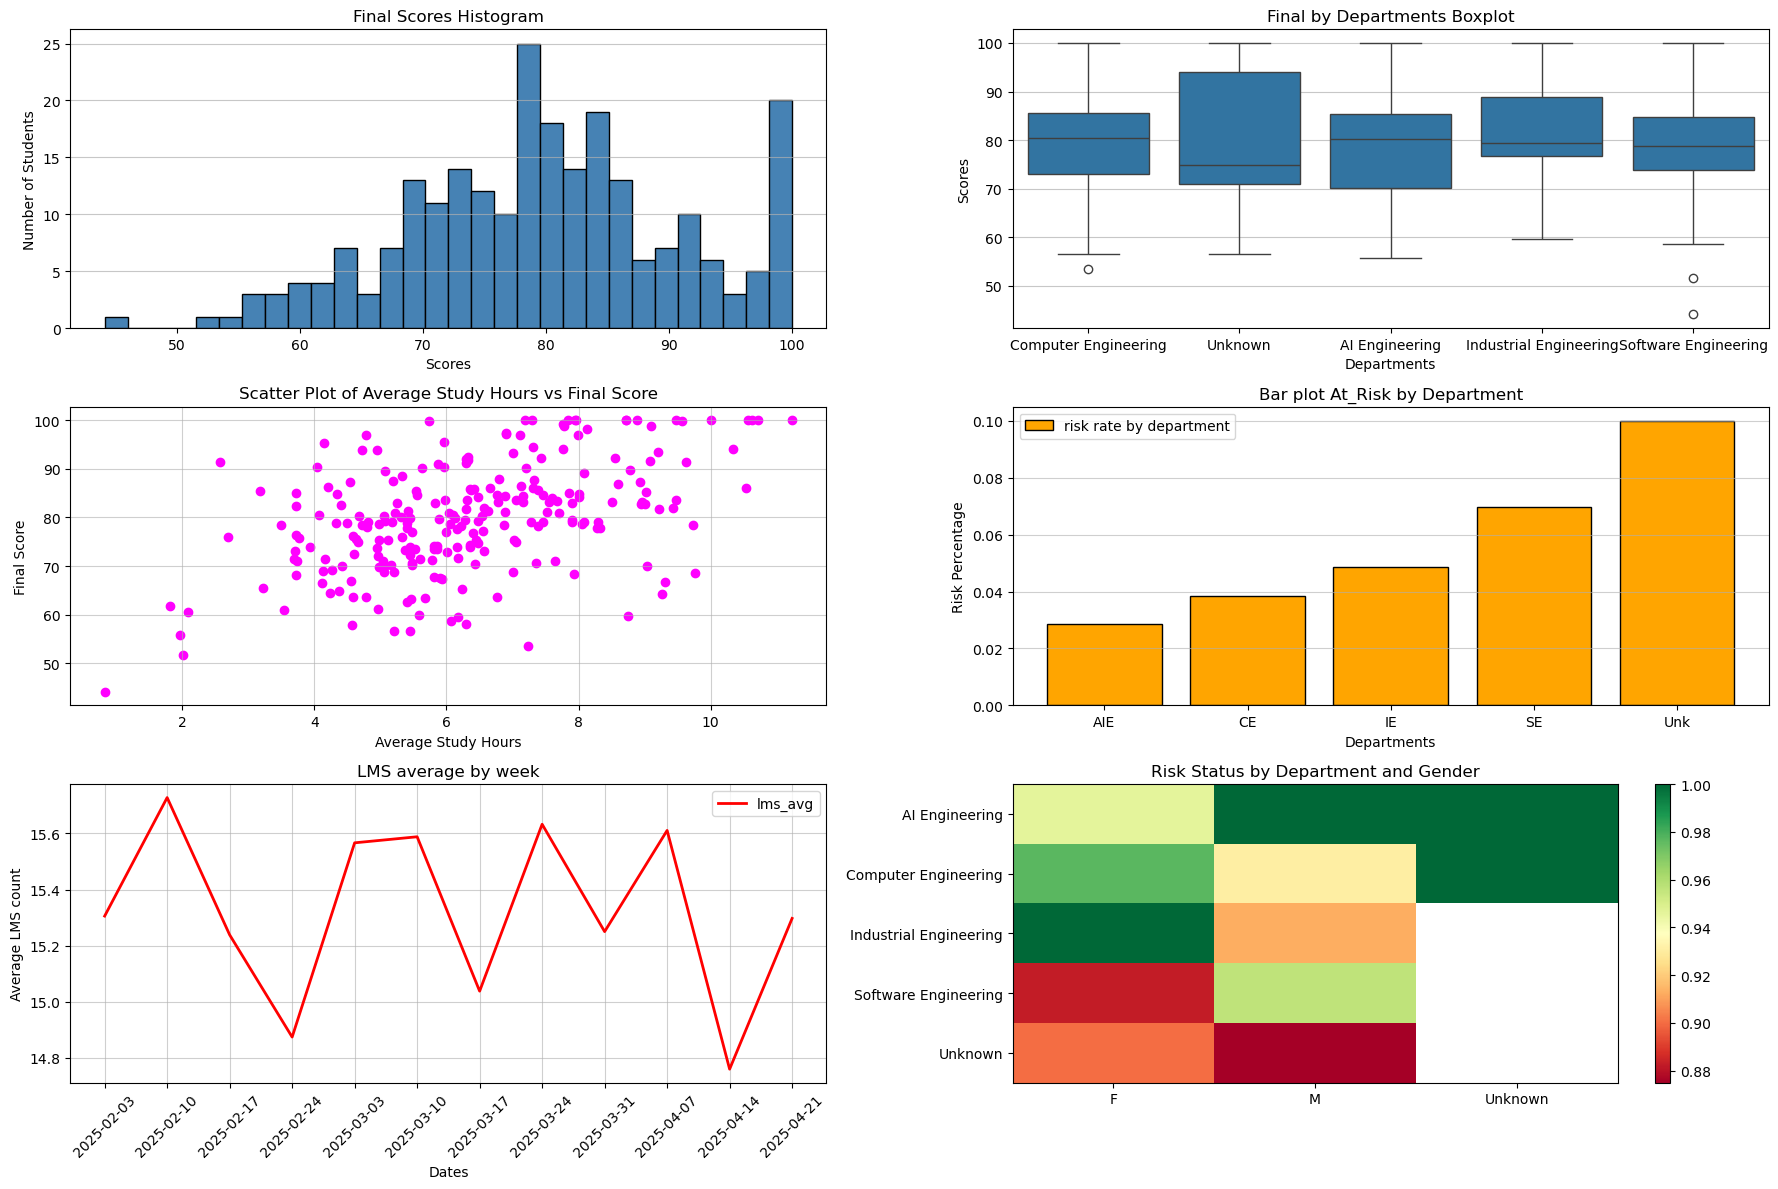

In [52]:
import seaborn as sns
fig, ax = plt.subplots(3, 2, figsize=(18, 12))
#i crated subplots to see all in one
ax = ax.flatten()
#it turns into a one line series rather than 2 by 3 matris.
ax[0].hist(merged_df["final_score"], bins = 30, color ="steelblue", edgecolor = "black")
ax[0].grid(True, axis = "y", alpha = 0.7)
ax[0].set_title("Final Scores Histogram")
ax[0].set_xlabel("Scores")
ax[0].set_ylabel("Number of Students")
# first graph is histogram
sns.boxplot(data = merged_df, x = "department", y = "final_score", ax = ax[1])
ax[1].grid(True, axis = "y", alpha = 0.7)
ax[1].set_title("Final by Departments Boxplot")
ax[1].set_xlabel("Departments")
ax[1].set_ylabel("Scores")
#Using seaborn is easier than pure matplotlib in here.
#second graph is boxplot
ax[2].scatter(merged_df["study_hours_mean"], merged_df["final_score"], color = "magenta")
ax[2].grid(True, alpha = 0.6)
ax[2].set_title("Scatter Plot of Average Study Hours vs Final Score")
ax[2].set_xlabel("Average Study Hours")
ax[2].set_ylabel("Final Score")
#third graph is scatter
department_names = ["AIE", "CE", "IE", "SE", "Unk"]
#I used acronyms for better visualizations.
risk_rate = [2/70, 3/78, 2/41, 3/43, 2/20]
#I check all of them manually then hardcoded.

ax[3].bar(department_names, risk_rate, color = "orange", label = "risk rate by department", edgecolor = "black")
ax[3].grid(True, alpha = 0.6, axis ="y")
ax[3].set_title("Bar plot At_Risk by Department")
ax[3].set_xlabel("Departments")
ax[3].set_ylabel("Risk Percentage")
ax[3].legend()
#forth graph is bar

df_week_lms = w_activity_df.groupby("week_start")["lms_logins"].mean()

ax[4].plot(df_week_lms, color = "red", linewidth = 2, label = "lms_avg")
ax[4].tick_params(axis='x', rotation=45)
ax[4].grid(True, alpha = 0.6)
ax[4].set_title("LMS average by week")
ax[4].set_xlabel("Dates")
ax[4].set_ylabel("Average LMS count")
ax[4].legend()
#fifth graph is regular plot
group_based_n = merged_df.groupby(["department", "gender"])["risk_status_encoded"].mean().unstack()
im = ax[5].imshow(group_based_n, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax[5])
ax[5].set_xticks(range(len(group_based_n.columns)))
ax[5].set_yticks(range(len(group_based_n.index)))
ax[5].set_xticklabels(group_based_n.columns)
ax[5].set_yticklabels(group_based_n.index)
ax[5].set_title("Risk Status by Department and Gender")
#sixth graph is heatmap-like

#for all i assinged a x_label, y_labe, title and for some label with legend not all because for some of them unnecessary. 
#Lastly, i put grid
plt.tight_layout()

In [53]:
#Task 6

In [60]:
#I convert week_start in earlier cell but to show im going to do again.
w_activity_df["week_start"].info()
#object.

<class 'pandas.core.series.Series'>
RangeIndex: 2880 entries, 0 to 2879
Series name: week_start
Non-Null Count  Dtype 
--------------  ----- 
2880 non-null   object
dtypes: object(1)
memory usage: 22.6+ KB


In [61]:
date.info()
#The converted version. I converted to datetime when i was analyzing data frames.

<class 'pandas.core.series.Series'>
RangeIndex: 2880 entries, 0 to 2879
Series name: week_start
Non-Null Count  Dtype         
--------------  -----         
2880 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 22.6 KB


In [63]:
print(f" first record of time: {date.min()}")
print(f" last record of time: {date.max()}")

 first record of time: 2025-02-03 00:00:00
 last record of time: 2025-04-21 00:00:00


In [80]:
print(f" unique weeks : {w_activity_df["week_start"].nunique()}")
print(f" values counts of week: {w_activity_df["week_start"].value_counts()}")

 unique weeks : 12
 values counts of week: week_start
2025-02-03    240
2025-02-10    240
2025-02-17    240
2025-02-24    240
2025-03-03    240
2025-03-10    240
2025-03-17    240
2025-03-24    240
2025-03-31    240
2025-04-07    240
2025-04-14    240
2025-04-21    240
Name: count, dtype: int64


In [94]:
date = pd.DataFrame(date)
#date.head()
indx_date = date.set_index("week_start")
indx_date.head()

""
week_start
2025-02-03
2025-02-10
2025-02-17
2025-02-24
2025-03-03


In [98]:
indx_date.loc["2025-02-03"].head()
#I selected 3 to 10 th days of the week.

""
week_start
2025-02-03
2025-02-03
2025-02-03
2025-02-03
2025-02-03


In [100]:
indx_date.sort_index().head()
#sorted by index.

""
week_start
2025-02-03
2025-02-03
2025-02-03
2025-02-03
2025-02-03


In [101]:
#task 6.3

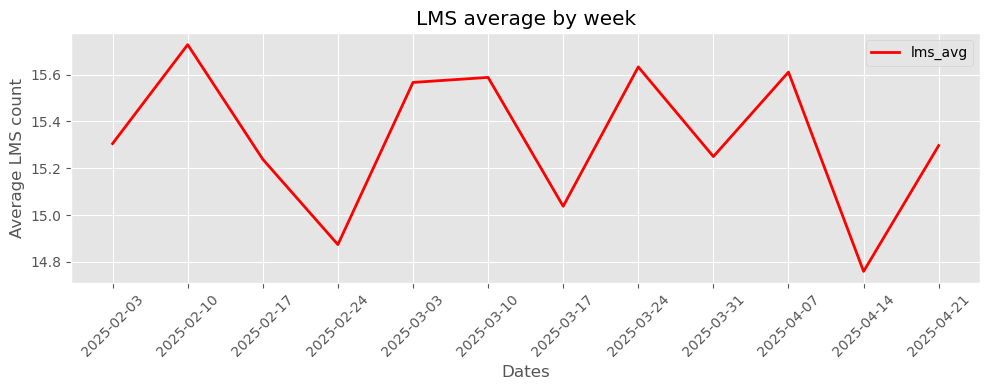

In [113]:
df_week_lms = w_activity_df.groupby("week_start")["lms_logins"].mean()
plt.style.use("ggplot")
plt.figure(figsize=(10,4))
plt.plot(df_week_lms, color = "red", linewidth = 2, label = "lms_avg")
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha = 1.0)
plt.title("LMS average by week")
plt.xlabel("Dates")
plt.ylabel("Average LMS count")
plt.legend()
plt.tight_layout()
#When the weeks continue there is no significant correlations. It just increases or dexreases no pattern.
#But after 2025-04-14 there is significant decreases in lms average something happend.

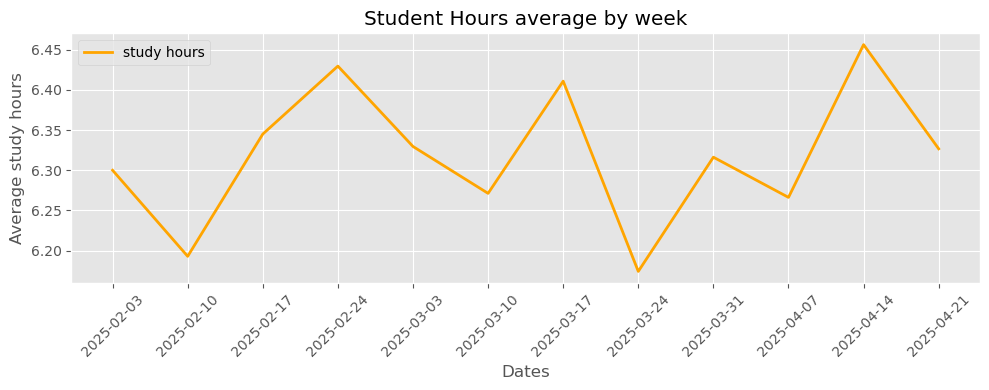

In [131]:
df_week_lms = w_activity_df.groupby("week_start")["study_hours"].mean()
plt.style.use("ggplot")
plt.figure(figsize=(10,4))
plt.plot(df_week_lms, color = "orange", linewidth = 2, label = "study hours")
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha = 1.0)
plt.title("Student Hours average by week")
plt.xlabel("Dates")
plt.ylabel("Average study hours")
plt.legend()
plt.tight_layout()
#In  2025-04-14 average study hours reached its peak level so it might be the final week.

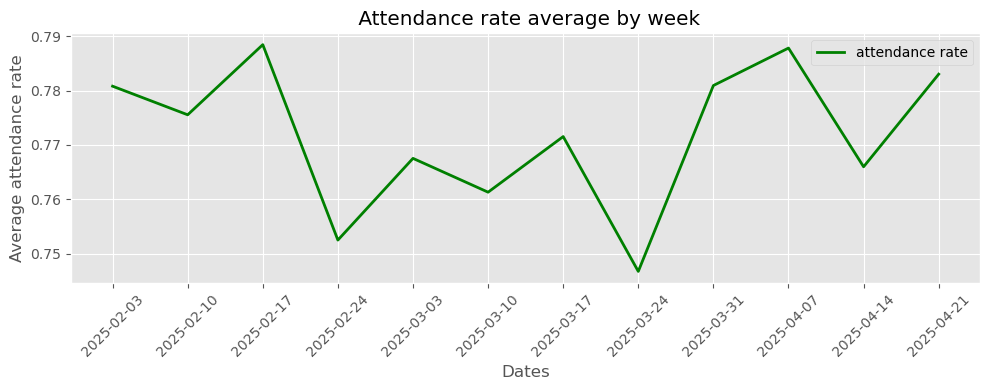

In [137]:
df_week_lms = w_activity_df.groupby("week_start")["attendance_rate"].mean()
plt.style.use("ggplot") 
plt.figure(figsize=(10,4))
plt.plot(df_week_lms, color = "green", linewidth = 2, label = "attendance rate")
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha = 1.0)
plt.title(" Attendance rate average by week")
plt.xlabel("Dates")
plt.ylabel("Average attendance rate")
plt.legend()
plt.tight_layout()
#As i said before it seems before finals attendance rates has increased.